In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### Read pre-training data from MERFISH. Inference data from CosMx and STARmap PLUS

In [4]:
adata_batch1=sc.read_h5ad("/home/dbj/SpaLP/gittest/Foundationtest/MERFISH.h5ad")
adata_batch1.obs['batch']='MERFISH'
adata_batch1.obs['type']='pre-train-data'


adata_batch2=sc.read_h5ad("/home/dbj/SpaLP/gittest/Foundationtest/STARmapPLUS.h5ad")
adata_batch2.obs['batch']='STARmapPLUS'
adata_batch2.obs['type']='Inference-data'
adata_batch3=sc.read_h5ad("/home/dbj/SpaLP/gittest/Foundationtest/CosMx.h5ad")
adata_batch3.obs['batch']='CosMx'
adata_batch3.obs['type']='Inference-data'
adata_batch1,adata_batch2,adata_batch3

(AnnData object with n_obs × n_vars = 49430 × 1122
     obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'batch', 'type'
     var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
     uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
     obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'spatial',
 AnnData object w

In [5]:
adata_list=[adata_batch1,adata_batch2,adata_batch3]
adata = ad.concat(adata_list, join="inner")

In [6]:
pre_train_data=adata[adata.obs['type']=='pre-train-data']
Inference_data=adata[adata.obs['type']=='Inference-data']

In [7]:
#Data preprocessing of pre-trained data
adatas = []
for batch in pre_train_data.obs['batch'].unique():
    a = pre_train_data[pre_train_data.obs['batch'] == batch].copy()
    sc.pp.normalize_total(a, inplace=True)
    sc.pp.log1p(a)
    sc.pp.scale(a)
    adatas.append(a)

pre_train_data = ad.concat(adatas, join="inner")
pre_train_data.obsm['feat']=pre_train_data.X

In [8]:
#Build neighborhood index using pre-trained data
pre_trained_graphs = []
for batch in pre_train_data.obs['batch'].unique():
    a = pre_train_data[pre_train_data.obs['batch'] == batch].copy()
    graph = prepare_inputs(a, k=12, device=device)
    pre_trained_graphs.append(graph)

In [9]:
all_features = torch.cat([g.features for g in pre_trained_graphs], dim=0)
all_neighbor_idx = []
offset = 0
for g in pre_trained_graphs:
    all_neighbor_idx.append(g.neighbor_idx + offset)
    offset += g.features.shape[0]
all_neighbor_idx = torch.cat(all_neighbor_idx, dim=0)

pre_trained_graph = Graph(all_features, all_neighbor_idx)

In [10]:
in_channels = pre_trained_graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
set_seed(7)
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(pre_trained_graph.features, pre_trained_graph.neighbor_idx)
    loss = criterion(reconstructed, pre_trained_graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:03<00:00, 61.28it/s, Epoch=199, Loss=0.9182]


In [12]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(pre_trained_graph.features, pre_trained_graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [13]:
pre_train_data.obsm['SpaLP']=embedding

In [14]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/cross-platform/set1/MERFISH_pretrian_model.pth")

In [15]:
pre_train_data.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/cross-platform/set1/Pre-training.h5ad',compression='gzip')

In [16]:
#Data preprocessing of inference data
adatas = []
for batch in Inference_data.obs['batch'].unique():
    a = Inference_data[Inference_data.obs['batch'] == batch].copy()
    sc.pp.normalize_total(a, inplace=True)
    sc.pp.log1p(a)
    sc.pp.scale(a)
    adatas.append(a)

Inference_data = ad.concat(adatas, join="inner")
Inference_data.obsm['feat']=Inference_data.X

In [17]:
#Build neighborhood index using inference data
Inference_graphs = []
for batch in Inference_data.obs['batch'].unique():
    a = Inference_data[Inference_data.obs['batch'] == batch]
    graph = prepare_inputs(a, k=12, device=device)
    Inference_graphs.append(graph)

In [18]:
all_features = torch.cat([g.features for g in Inference_graphs], dim=0)
all_neighbor_idx = []
offset = 0
for g in Inference_graphs:
    all_neighbor_idx.append(g.neighbor_idx + offset)
    offset += g.features.shape[0]
all_neighbor_idx = torch.cat(all_neighbor_idx, dim=0)

Inference_graph = Graph(all_features, all_neighbor_idx)

In [19]:
in_channels = Inference_graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/cross-platform/set1/MERFISH_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(Inference_graph.features, Inference_graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

Inference_data.obsm['SpaLP']=embedding

In [20]:
adata=sc.concat([pre_train_data,Inference_data])

In [21]:
sc.pp.neighbors(adata, use_rep='SpaLP',n_neighbors=30)
sc.tl.umap(adata)

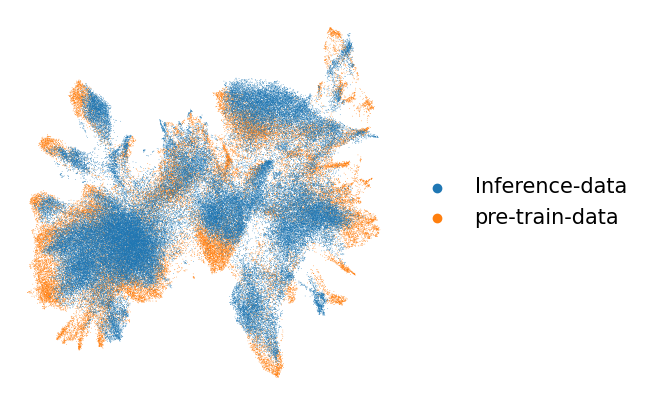

In [22]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['font.size'] = 15
sc.pl.umap(adata=adata,color='type',title='',size=1,colorbar_loc=None,frameon=False)

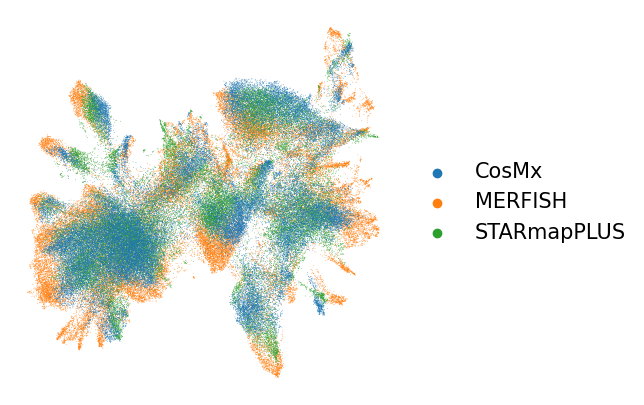

In [29]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['font.size'] = 15
sc.pl.umap(adata=adata,color='batch',title='',size=1,colorbar_loc=None,frameon=False)